## SECTION 1: Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
# Define paths
# Note: Update the DATA_ROOT path to point to the local copy of the LFW dataset
# and the prepocessed images will be saved in the OUTPUT_DIR
DATA_ROOT = Path(r"raw_data/lfw-deepfunneled/lfw-deepfunneled")
OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

In [24]:
# minimum images per person (justified in the report)
MIN_IMAGES   = 3          # satisfies both contrastive and triplet loss requirements
MAX_IMAGES   = 50         # cap to prevent class dominance, can be 30
IMG_SIZE     = (105, 105) # resize target (H, W)
TEST_SPLIT   = 0.2        # 20% of persons go to test set
RANDOM_SEED  = 42

TRAIN_SPLIT = 0.70        # 70% of eligible persons → training
VAL_SPLIT   = 0.15        # 15% of eligible persons → validation (threshold tuning)
TEST_SPLIT  = 0.15        # 15% of eligible persons → final evaluation (10-model comparison)
RANDOM_SEED = 42

# PAIRS_PER_PERSON    = 5   # positive pairs to generate per person
# TRIPLETS_PER_PERSON = 5   # triplets to generate per person

# After experimentation, these values were increased to 20 to provide more training data for the model,
# which can help improve performance and generalization.
PAIRS_PER_PERSON    = 20
TRIPLETS_PER_PERSON = 20

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## SECTION 2: Raw Data Exploration

In [4]:
# Dataset statistics
person_image_counts = {}

for person_folder in DATA_ROOT.iterdir():
    if person_folder.is_dir():
        images = list(person_folder.glob("*.jpg"))
        person_image_counts[person_folder.name] = len(images)

total_persons = len(person_image_counts)
total_images  = sum(person_image_counts.values())
counts        = list(person_image_counts.values())

print(f"  Total persons : {total_persons:,}")
print(f"  Total images  : {total_images:,}")
print(f"  Min images    : {min(counts)}")
print(f"  Max images    : {max(counts)}")
print(f"  Mean images   : {np.mean(counts):.2f}")
print(f"  Median images : {np.median(counts):.2f}")

# count how many people have only 1 image (useless for training)
only_one = sum(1 for c in counts if c == 1)
print(f"\n  People with only 1 image : {only_one:,} "
      f"({100*only_one/total_persons:.1f}% of dataset)")
print(f" These are USELESS for training — cannot form any pair or triplet")

  Total persons : 5,749
  Total images  : 13,233
  Min images    : 1
  Max images    : 530
  Mean images   : 2.30
  Median images : 1.00

  People with only 1 image : 4,069 (70.8% of dataset)
 These are USELESS for training — cannot form any pair or triplet


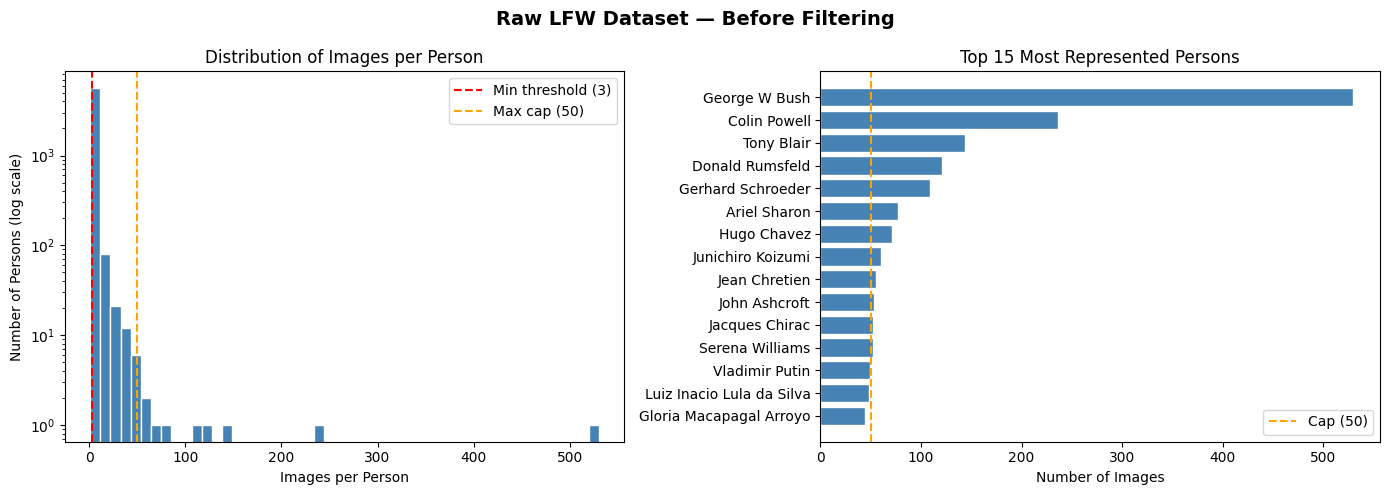

 Plot saved to processed_data/01_raw_distribution.png


In [5]:
# Visualize raw distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Raw LFW Dataset — Before Filtering", fontsize=14, fontweight='bold')

# Left: full histogram (log scale to handle skew)
axes[0].hist(counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel("Images per Person")
axes[0].set_ylabel("Number of Persons (log scale)")
axes[0].set_title("Distribution of Images per Person")
axes[0].axvline(MIN_IMAGES, color='red',    linestyle='--', label=f'Min threshold ({MIN_IMAGES})')
axes[0].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Max cap ({MAX_IMAGES})')
axes[0].legend()

# Right: top 15 most represented persons
top15 = sorted(person_image_counts.items(), key=lambda x: x[1], reverse=True)[:15]
names, img_counts = zip(*top15)
short_names = [n.replace('_', ' ') for n in names]

axes[1].barh(short_names[::-1], img_counts[::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel("Number of Images")
axes[1].set_title("Top 15 Most Represented Persons")
axes[1].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Cap ({MAX_IMAGES})')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_raw_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/01_raw_distribution.png")

In [6]:
# Filtering impact analysis
# Show how many persons survive at different thresholds
# This JUSTIFIES my choice of MIN_IMAGES = 3

thresholds = [1, 2, 3, 4, 5, 10]
print("\n Filtering Impact Analysis:")
print(f" {'Min Threshold':<18} {'Eligible Persons':<20} {'% Retained'}")
for t in thresholds:
    eligible = sum(1 for c in counts if c >= t)
    pct = 100 * eligible / total_persons
    marker = " our choice" if t == MIN_IMAGES else ""
    print(f"  {t:<18} {eligible:<20,} {pct:.1f}%{marker}")



 Filtering Impact Analysis:
 Min Threshold      Eligible Persons     % Retained
  1                  5,749                100.0%
  2                  1,680                29.2%
  3                  901                  15.7% our choice
  4                  610                  10.6%
  5                  423                  7.4%
  10                 158                  2.7%


## SECTION 3: Filtering & Person-Level Split


In [7]:
# Apply min/max filter to get the final list of eligible persons for training
eligible_persons = {
    person: count 
    for person, count in person_image_counts.items()
    if MIN_IMAGES <= count <= (MAX_IMAGES)
}

filtered_counts = list(eligible_persons.values())
filtered_names  = list(eligible_persons.keys())
print("\n After applying min/max filter:")
print(f"  Eligible persons : {len(eligible_persons):,}")
print(f"  Total images     : {sum(filtered_counts):,}")
print(f"  Min images       : {min(filtered_counts)}")
print(f"  Max images       : {max(filtered_counts)}")
print(f"  Mean images      : {np.mean(filtered_counts):.2f}")
print(f"  Median images    : {np.median(filtered_counts):.2f}")


 After applying min/max filter:
  Eligible persons : 889
  Total images     : 6,046
  Min images       : 3
  Max images       : 49
  Mean images      : 6.80
  Median images    : 4.00


In [8]:
# Split persons NOT images — this is the open-set protocol
# Persons in test are completely unseen during training

train_persons, temp_persons = train_test_split(
    filtered_names,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED
)

val_persons, test_persons = train_test_split(
    temp_persons,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED
)

# Display split statistics
print(f"  Train persons : {len(train_persons):,} ({100*len(train_persons)/len(filtered_names):.1f}%)")
print(f"  Val persons   : {len(val_persons):,}  ({100*len(val_persons)/len(filtered_names):.1f}%)")
print(f"  Test persons  : {len(test_persons):,}  ({100*len(test_persons)/len(filtered_names):.1f}%)")

# Sanity check — confirm zero overlap
assert len(set(train_persons) & set(val_persons))  == 0, "Overlap between train and val"
assert len(set(train_persons) & set(test_persons)) == 0, "Overlap between train and test"
assert len(set(val_persons)   & set(test_persons)) == 0, "Overlap between val and test"

  Train persons : 622 (70.0%)
  Val persons   : 133  (15.0%)
  Test persons  : 134  (15.1%)


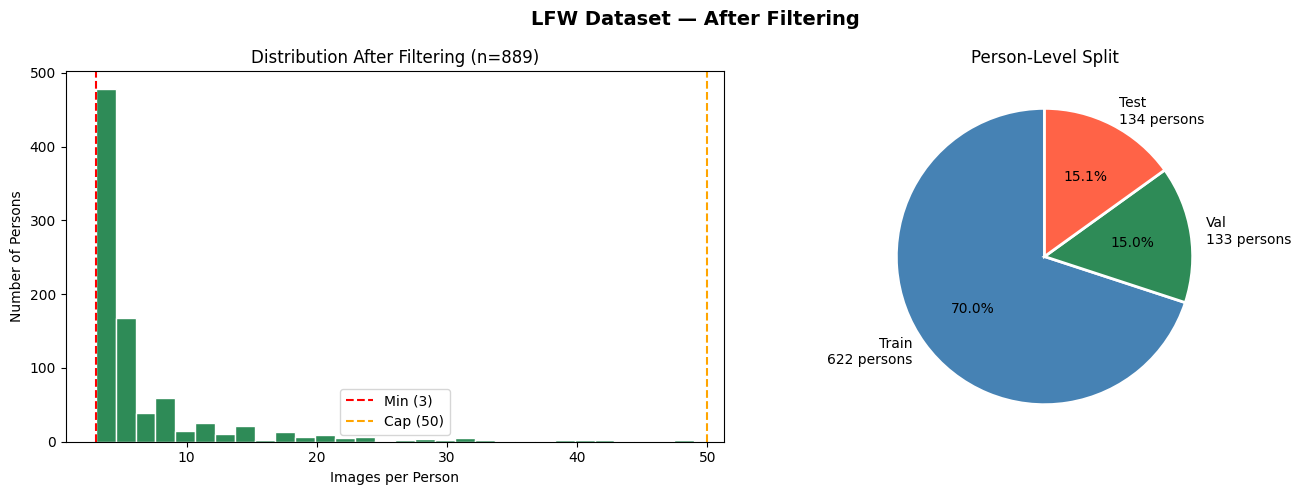

 Plot saved to processed_data/02_filtered_distribution.png


In [9]:
# Visualize filtered distribution and split breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LFW Dataset — After Filtering", fontsize=14, fontweight='bold')

# Left: filtered histogram
axes[0].hist(filtered_counts, bins=30, color='seagreen', edgecolor='white')
axes[0].set_xlabel("Images per Person")
axes[0].set_ylabel("Number of Persons")
axes[0].set_title(f"Distribution After Filtering (n={len(eligible_persons):,})")
axes[0].axvline(MIN_IMAGES, color='red',    linestyle='--', label=f'Min ({MIN_IMAGES})')
axes[0].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Cap ({MAX_IMAGES})')
axes[0].legend()

# Right: split breakdown pie chart
split_labels = [
    f'Train\n{len(train_persons)} persons',
    f'Val\n{len(val_persons)} persons',
    f'Test\n{len(test_persons)} persons'
]
split_sizes  = [len(train_persons), len(val_persons), len(test_persons)]
colors       = ['steelblue', 'seagreen', 'tomato']

axes[1].pie(split_sizes, labels=split_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Person-Level Split")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_filtered_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/02_filtered_distribution.png")

## SECTION 4: Image Preprocessing & Augmentation

In [10]:
# Image preprocessing function
def preprocess_image(img_path):
    # Load, resize, and normalize a single image.
    # Returns float32 array of shape (224, 224, 3) in range [0, 1]
    # why? - resizing to a common size is needed for batch processing and model input
    # normalization to [0, 1] is common for neural network inputs to improve training stability
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR by default
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0        # normalize to [0, 1]
    return img


# Offline augmentation functions
def augment_image(img):
    # Apply a random combination of augmentations to a single image.
    # All augmentations are label-preserving for face verification.
    img = img.copy()

    # Horizontal flip (50% chance)
    if random.random() > 0.5:
        img = np.fliplr(img)

    # Small rotation ±15 degrees
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h))

    # Brightness adjustment
    if random.random() > 0.5:
        factor = random.uniform(0.7, 1.3)
        img    = np.clip(img * factor, 0, 1)

    # Contrast adjustment
    if random.random() > 0.5:
        mean   = img.mean()
        factor = random.uniform(0.8, 1.2)
        img    = np.clip((img - mean) * factor + mean, 0, 1)

    # Saturation adjustment
    if random.random() > 0.5:
        img_uint8 = (img * 255).astype(np.uint8)
        img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV).astype(np.float32)
        img_hsv[:,:,1] = np.clip(img_hsv[:,:,1] * random.uniform(0.7, 1.3), 0, 255)
        img_uint8 = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        img = img_uint8.astype(np.float32) / 255.0

    # Mild Gaussian blur
    if random.random() > 0.7:    # less frequent than others
        img_uint8 = (img * 255).astype(np.uint8)
        img_uint8 = cv2.GaussianBlur(img_uint8, (3, 3), 0)
        img       = img_uint8.astype(np.float32) / 255.0

    # AWGN — subtle noise
    if random.random() > 0.7:    # less frequent than others
        noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
        img   = np.clip(img + noise, 0, 1)

    return img

In [11]:
# Load and augment all persons
# Training persons: load + augment up to MAX_IMAGES
# Val/Test persons: load only, no augmentation

def load_person_images(person_name, augment=False):
    person_path = DATA_ROOT / person_name
    img_paths = list(person_path.glob("*.jpg"))
    images = [preprocess_image(p) for p in img_paths]

    if augment and len(images) < MAX_IMAGES:
        original_images = images.copy()
        attempts = 0
        max_attempts = MAX_IMAGES * 3  # safety limit

        while len(images) < MAX_IMAGES and attempts < max_attempts:
            base_img = random.choice(original_images)
            aug_img  = augment_image(base_img)
            images.append(aug_img)
            attempts += 1

    return images

In [12]:
# building image bank for all splits
# image_bank = { person_name: [img1, img2, ...] }

train_bank = {}
for person in tqdm(train_persons):
    train_bank[person] = load_person_images(person, augment=True)

val_bank = {}
for person in tqdm(val_persons):
    val_bank[person] = load_person_images(person, augment=False)

test_bank = {}
for person in tqdm(test_persons):
    test_bank[person] = load_person_images(person, augment=False)

train_total = sum(len(v) for v in train_bank.values())
val_total   = sum(len(v) for v in val_bank.values())
test_total  = sum(len(v) for v in test_bank.values())

print(f"  Train images : {train_total:,} (was {sum(eligible_persons[p] for p in train_persons):,} before augmentation)")
print(f"  Val images   : {val_total:,}")
print(f"  Test images  : {test_total:,}")

100%|██████████| 134/134 [00:09<00:00, 14.22it/s]

  Train images : 31,100 (was 4,263 before augmentation)
  Val images   : 876
  Test images  : 907


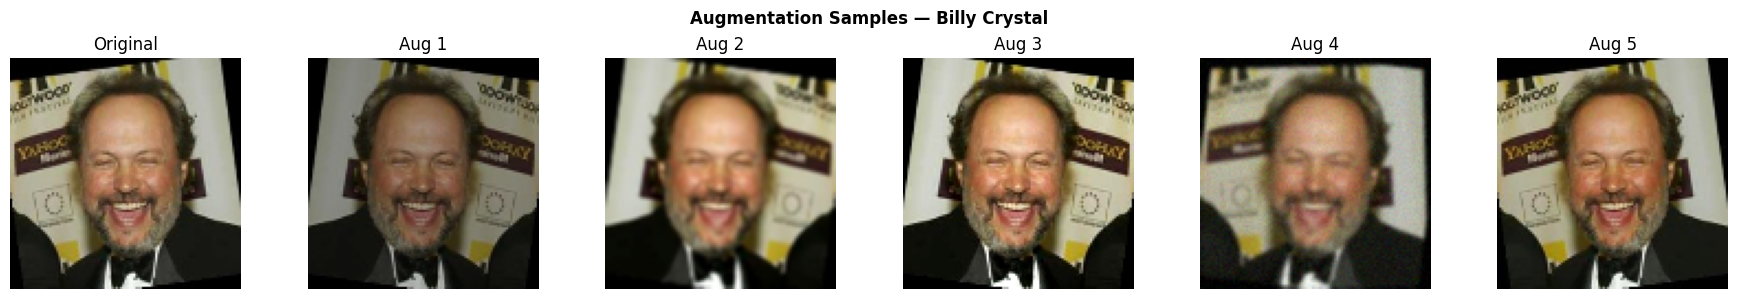

 Plot saved to processed_data/03_augmentation_samples.png


In [15]:
# Visualize augmentation samples
# Show original + 5 augmented versions of one person

sample_person = train_persons[100]
sample_images = train_bank[sample_person]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle(f"Augmentation Samples — {sample_person.replace('_', ' ')}",fontsize=12, fontweight='bold')

# Original
orig_path = list((DATA_ROOT / sample_person).glob("*.jpg"))[0]
orig_img  = preprocess_image(orig_path)
axes[0].imshow(orig_img)
axes[0].set_title("Original")
axes[0].axis('off')

# 5 augmented versions
for i in range(1, 6):
    aug = augment_image(orig_img)
    axes[i].imshow(aug)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_augmentation_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/03_augmentation_samples.png")

## SECTION 5: Pair & Triplet Generation

In [25]:
# Pair generation function
def generate_pairs(image_bank, pairs_per_person):

    X1, X2, labels = [], [], []
    persons = list(image_bank.keys()) # get list of person names in the bank

    for person in tqdm(persons):
        imgs = image_bank[person]
        if len(imgs) < 2: # sanity check, should not happen due to filtering, but just in case
            continue

        # Positive pairs (same person)
        pos_pairs = list(range(len(imgs)))
        random.shuffle(pos_pairs)
        count = 0

        for j in range(len(imgs)):
            for k in range(j + 1, len(imgs)):
                if count >= pairs_per_person:
                    break
                X1.append(imgs[j])
                X2.append(imgs[k])
                labels.append(1)
                count += 1
            if count >= pairs_per_person:
                break

        # Negative pairs (different person) 1:1 ratio
        other_persons = [p for p in persons if p != person]
        neg_count = 0

        while neg_count < count:   # match exactly how many positives we made
            other_person = random.choice(other_persons)
            other_imgs   = image_bank[other_person]
            X1.append(random.choice(imgs))
            X2.append(random.choice(other_imgs))
            labels.append(0)
            neg_count += 1

    return (np.array(X1, dtype=np.float32),
            np.array(X2, dtype=np.float32),
            np.array(labels, dtype=np.int32))
print("done")

done


In [26]:
# Triplet generation function
def generate_triplets(image_bank, triplets_per_person):

    anchors, positives, negatives = [], [], []
    persons = list(image_bank.keys())

    for person in tqdm(persons):
        imgs = image_bank[person]
        if len(imgs) < 2: # the same sanity check as before
            continue

        other_persons = [p for p in persons if p != person]
        count = 0

        for j in range(len(imgs)):
            for k in range(j + 1, len(imgs)):
                if count >= triplets_per_person:
                    break

                # anchor and positive from same person
                anchor   = imgs[j]
                positive = imgs[k]

                # negative from a different person
                neg_person = random.choice(other_persons)
                negative   = random.choice(image_bank[neg_person])

                anchors.append(anchor)
                positives.append(positive)
                negatives.append(negative)
                count += 1

            if count >= triplets_per_person:
                break

    return (np.array(anchors,   dtype=np.float32),
            np.array(positives, dtype=np.float32),
            np.array(negatives, dtype=np.float32))

print("done")

done


In [27]:
# Generate all splits 

print("Gen TRAINING pairs")
train_X1, train_X2, train_pair_labels = generate_pairs(train_bank, PAIRS_PER_PERSON)

print("\nGen VALIDATION pairs")
val_X1, val_X2, val_pair_labels = generate_pairs(val_bank, PAIRS_PER_PERSON)

print("\nGen TEST pairs")
test_X1, test_X2, test_pair_labels = generate_pairs(test_bank, PAIRS_PER_PERSON)

print("\nGen TRAINING triplets")
train_anchors, train_positives, train_negatives = generate_triplets(train_bank, TRIPLETS_PER_PERSON)

print("\nGen VALIDATION triplets")
val_anchors, val_positives, val_negatives = generate_triplets(val_bank, TRIPLETS_PER_PERSON)

print("\nGen TEST triplets")
test_anchors, test_positives, test_negatives = generate_triplets(test_bank, TRIPLETS_PER_PERSON)

Gen TRAINING pairs


  0%|          | 0/622 [00:00<?, ?it/s]

100%|██████████| 622/622 [00:00<00:00, 4421.73it/s]



Gen VALIDATION pairs


100%|██████████| 133/133 [00:00<00:00, 4000.13it/s]


...

100%|██████████| 622/622 [00:00<00:00, 4186.96it/s]



Gen VALIDATION triplets


100%|██████████| 133/133 [00:00<00:00, 18170.17it/s]



Gen TEST triplets


100%|██████████| 134/134 [00:00<00:00, 7664.49it/s]


In [28]:
# Report generation results
print(f"  PAIRS")
print(f"  Train: {len(train_pair_labels):,} total "
      f"({train_pair_labels.sum():,} pos / {(train_pair_labels==0).sum():,} neg)")
print(f"  Val: {len(val_pair_labels):,} total "
      f"({val_pair_labels.sum():,} pos / {(val_pair_labels==0).sum():,} neg)")
print(f"  Test: {len(test_pair_labels):,} total "
      f"({test_pair_labels.sum():,} pos / {(test_pair_labels==0).sum():,} neg)")
print()
print(f"  TRIPLETS")
print(f"  Train: {len(train_anchors):,}")
print(f"  Val: {len(val_anchors):,}")
print(f"  Test:  {len(test_anchors):,}")

# why assert function?
# The assert function is used to verify that a condition is true.
# If the condition is false, it raises an AssertionError with the specified message.
# here it checks that the number of positive pairs (label=1) 
# is equal to the number of negative pairs (label=0) in each split,
# confirming the intended 1:1 ratio.
# If this condition is not met, it will raise an error with a message indicating which split has the issue.
assert train_pair_labels.sum() == (train_pair_labels==0).sum(), "Train pairs not 1:1!"
assert val_pair_labels.sum() == (val_pair_labels==0).sum(),   "Val pairs not 1:1!"
assert test_pair_labels.sum() == (test_pair_labels==0).sum(),  "Test pairs not 1:1!"

  PAIRS
  Train: 24,880 total (12,440 pos / 12,440 neg)
  Val: 2,558 total (1,279 pos / 1,279 neg)
  Test: 2,688 total (1,344 pos / 1,344 neg)

  TRIPLETS
  Train: 12,440
  Val: 1,279
  Test:  1,344


In [29]:
# Save to .npz files

print("Saving pairs...")
np.savez_compressed(OUTPUT_DIR / "pairs_train.npz",
                    X1=train_X1, X2=train_X2, labels=train_pair_labels)
np.savez_compressed(OUTPUT_DIR / "pairs_val.npz",
                    X1=val_X1,   X2=val_X2,   labels=val_pair_labels)
np.savez_compressed(OUTPUT_DIR / "pairs_test.npz",
                    X1=test_X1,  X2=test_X2,  labels=test_pair_labels)

print("Saving triplets...")
np.savez_compressed(OUTPUT_DIR / "triplets_train.npz",
                    anchors=train_anchors, positives=train_positives, negatives=train_negatives)
np.savez_compressed(OUTPUT_DIR / "triplets_val.npz",
                    anchors=val_anchors,   positives=val_positives,   negatives=val_negatives)
np.savez_compressed(OUTPUT_DIR / "triplets_test.npz",
                    anchors=test_anchors,  positives=test_positives,  negatives=test_negatives)

Saving pairs...
Saving triplets...


In [31]:
print("\nAll files saved to processed_data/")
for f in sorted(OUTPUT_DIR.glob("*.npz")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{f.name:<30} {size_mb:.1f} MB")


All files saved to processed_data/
pairs_test.npz                 187.4 MB
pairs_train.npz                2644.0 MB
pairs_val.npz                  180.5 MB
triplets_test.npz              140.5 MB
triplets_train.npz             1888.0 MB
triplets_val.npz               135.4 MB


## Checks and Visualizations

In [35]:
# Load data to confirm everything works
pairs_train = np.load(OUTPUT_DIR / "pairs_train.npz")
pairs_val= np.load(OUTPUT_DIR / "pairs_val.npz")
pairs_test = np.load(OUTPUT_DIR / "pairs_test.npz")
triplets_train= np.load(OUTPUT_DIR / "triplets_train.npz")
triplets_val= np.load(OUTPUT_DIR / "triplets_val.npz")
triplets_test = np.load(OUTPUT_DIR / "triplets_test.npz")
print("everything works")

everything works


In [36]:
# Shape & value checks
# Pairs
for name, data in [("pairs_train", pairs_train),
                   ("pairs_val",   pairs_val),
                   ("pairs_test",  pairs_test)]:
    X1     = data['X1']
    X2     = data['X2']
    labels = data['labels']
    print(f"\n  {name}")
    print(f"    X1 shape     : {X1.shape}")
    print(f"    X2 shape     : {X2.shape}")
    print(f"    Labels shape : {labels.shape}")
    print(f"    Pixel range  : [{X1.min():.2f}, {X1.max():.2f}]")
    print(f"    Pos/Neg      : {labels.sum()} / {(labels==0).sum()}")

# Triplets
for name, data in [("triplets_train", triplets_train),
                   ("triplets_val",   triplets_val),
                   ("triplets_test",  triplets_test)]:
    anchors   = data['anchors']
    positives = data['positives']
    negatives = data['negatives']
    print(f"\n  {name}")
    print(f"    Anchors shape   : {anchors.shape}")
    print(f"    Positives shape : {positives.shape}")
    print(f"    Negatives shape : {negatives.shape}")
    print(f"    Pixel range     : [{anchors.min():.2f}, {anchors.max():.2f}]")


  pairs_train
    X1 shape     : (24880, 105, 105, 3)
    X2 shape     : (24880, 105, 105, 3)
    Labels shape : (24880,)
    Pixel range  : [0.00, 1.00]
    Pos/Neg      : 12440 / 12440

  pairs_val
    X1 shape     : (2558, 105, 105, 3)
    X2 shape     : (2558, 105, 105, 3)
    Labels shape : (2558,)
    Pixel range  : [0.00, 1.00]
    Pos/Neg      : 1279 / 1279

  pairs_test
    X1 shape     : (2688, 105, 105, 3)
    X2 shape     : (2688, 105, 105, 3)
    Labels shape : (2688,)
    Pixel range  : [0.00, 1.00]
    Pos/Neg      : 1344 / 1344

  triplets_train
    Anchors shape   : (12440, 105, 105, 3)
    Positives shape : (12440, 105, 105, 3)
    Negatives shape : (12440, 105, 105, 3)
    Pixel range     : [0.00, 1.00]

  triplets_val
    Anchors shape   : (1279, 105, 105, 3)
    Positives shape : (1279, 105, 105, 3)
    Negatives shape : (1279, 105, 105, 3)
    Pixel range     : [0.00, 1.00]

  triplets_test
    Anchors shape   : (1344, 105, 105, 3)
    Positives shape : (1344, 10

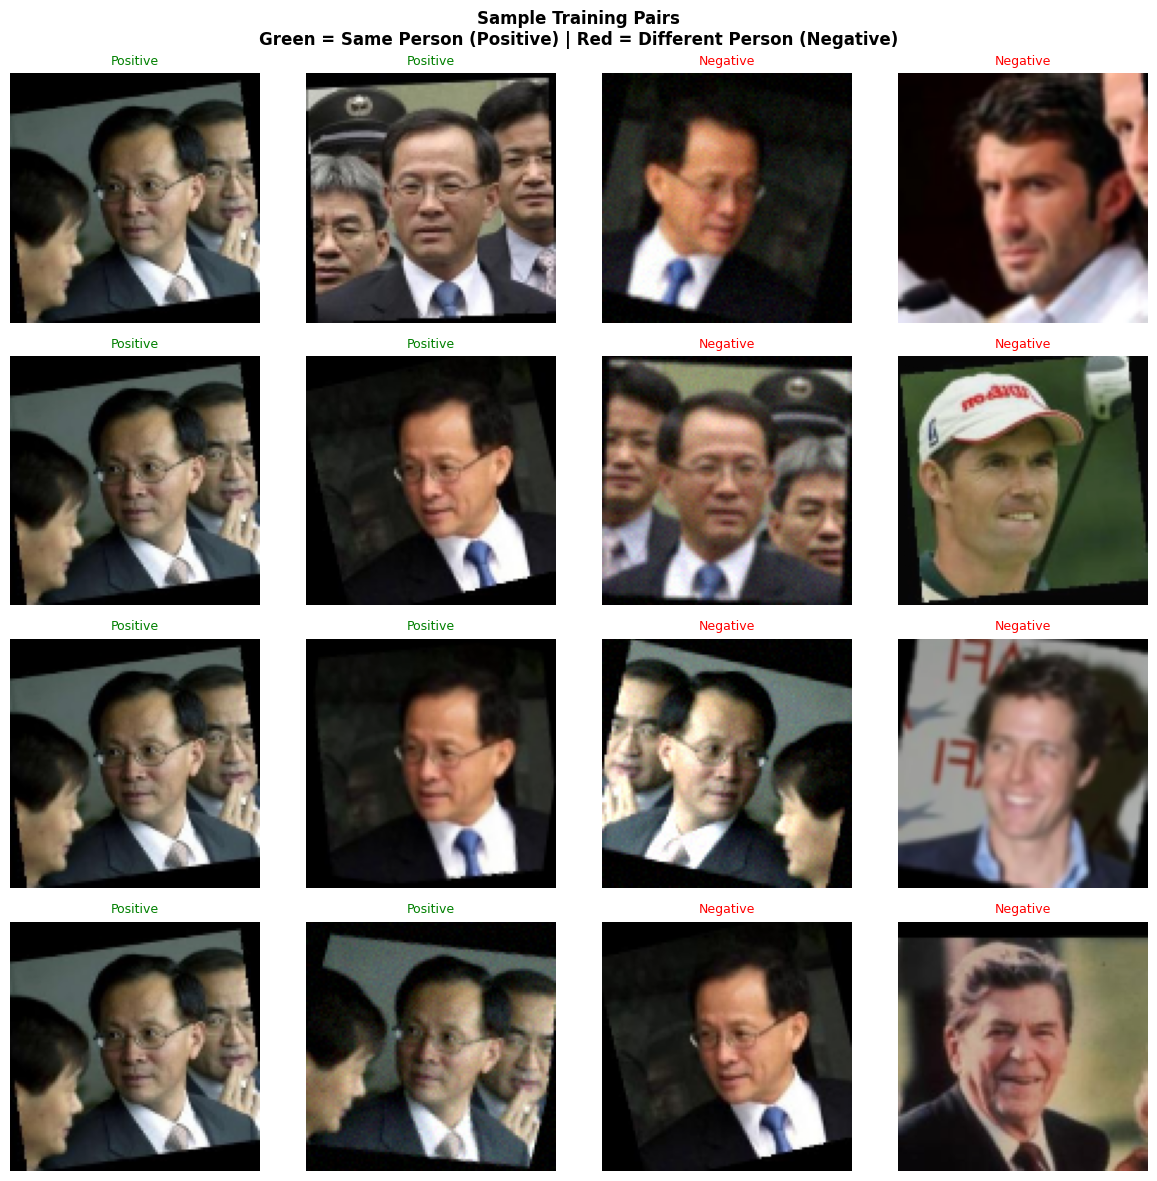

 Plot saved to processed_data/05_sample_pairs.png


In [37]:
# Visualize sample pairs

X1 = pairs_train['X1']
X2 = pairs_train['X2']
labels = pairs_train['labels']

# Pick 4 positive and 4 negative pairs
pos_idx = np.where(labels == 1)[0][:4]
neg_idx = np.where(labels == 0)[0][:4]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Sample Training Pairs\nGreen = Same Person (Positive) | Red = Different Person (Negative)",
             fontsize=12, fontweight='bold')

for i, idx in enumerate(pos_idx):
    axes[i, 0].imshow(X1[idx])
    axes[i, 0].set_title("Positive", color='green', fontsize=9)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(X2[idx])
    axes[i, 1].set_title("Positive", color='green', fontsize=9)
    axes[i, 1].axis('off')

for i, idx in enumerate(neg_idx):
    axes[i, 2].imshow(X1[idx])
    axes[i, 2].set_title("Negative", color='red', fontsize=9)
    axes[i, 2].axis('off')
    axes[i, 3].imshow(X2[idx])
    axes[i, 3].set_title("Negative", color='red', fontsize=9)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_sample_pairs.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/05_sample_pairs.png")

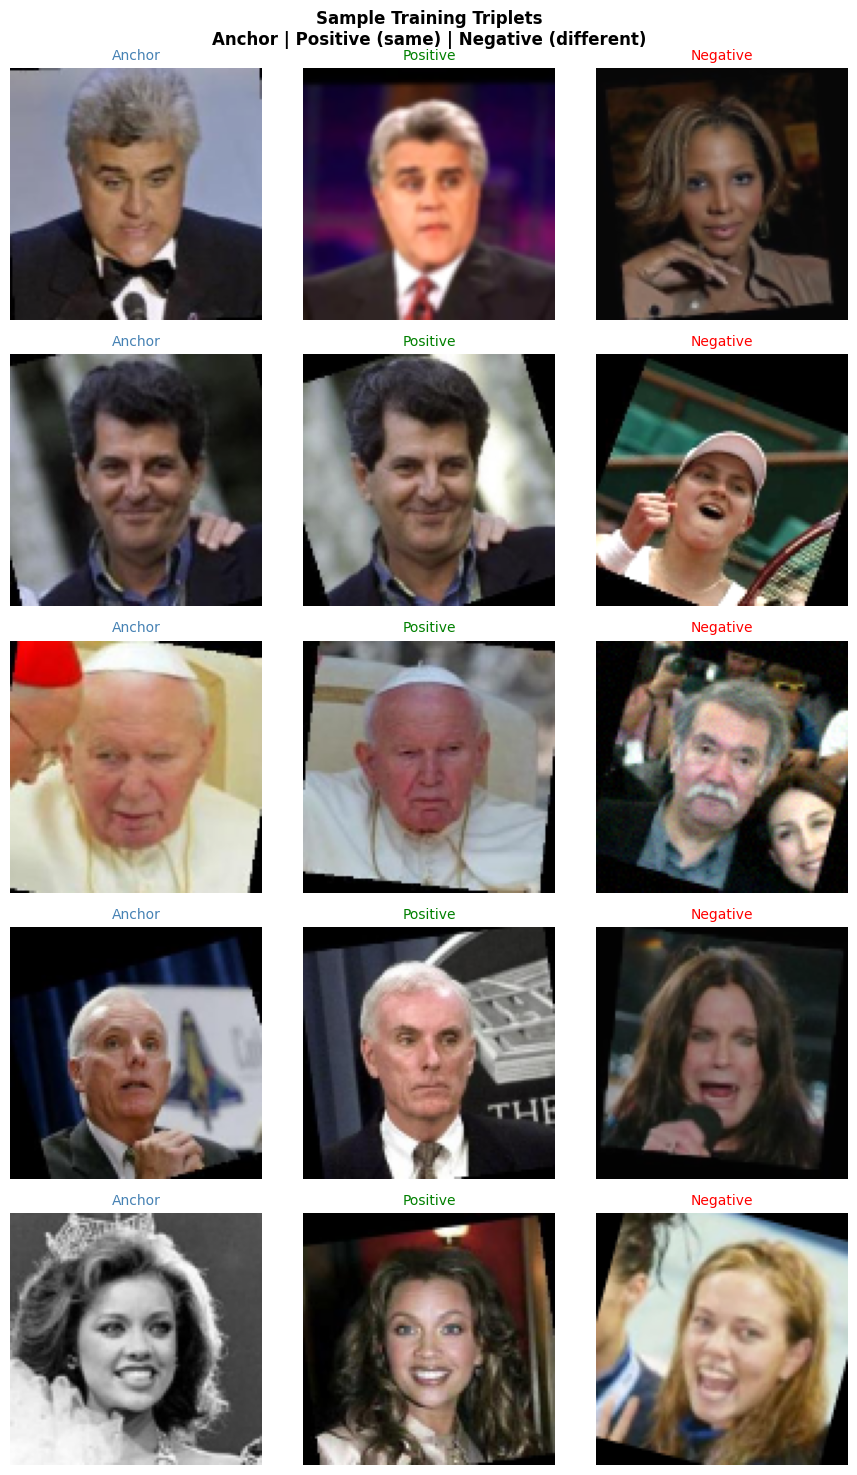

Plot saved to processed_data/06_sample_triplets.png


In [38]:
# Visualize sample triplets

anchors   = triplets_train['anchors']
positives = triplets_train['positives']
negatives = triplets_train['negatives']

num_samples = 5
indices     = random.sample(range(len(anchors)), num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
fig.suptitle("Sample Training Triplets\nAnchor | Positive (same) | Negative (different)",
             fontsize=12, fontweight='bold')

col_titles = ['Anchor', 'Positive', 'Negative']
colors     = ['steelblue', 'green', 'red']

for i, idx in enumerate(indices):
    for j, (img, title, color) in enumerate(zip(
        [anchors[idx], positives[idx], negatives[idx]],
        col_titles, colors
    )):
        axes[i, j].imshow(img)
        axes[i, j].set_title(title, color=color, fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_sample_triplets.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to processed_data/06_sample_triplets.png")

In [39]:
# Final file inventory
for f in sorted(OUTPUT_DIR.glob("*")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<35} {size_mb:.1f} MB")

  01_raw_distribution.png             0.1 MB
  02_filtered_distribution.png        0.1 MB
  03_augmentation_samples.png         0.2 MB
  04_raw_vs_augmented.png             0.4 MB
  05_sample_pairs.png                 0.5 MB
  06_sample_triplets.png              0.5 MB
  pairs_test.npz                      187.4 MB
  pairs_train.npz                     2644.0 MB
  pairs_val.npz                       180.5 MB
  triplets_test.npz                   140.5 MB
  triplets_train.npz                  1888.0 MB
  triplets_val.npz                    135.4 MB
